## Satellite Machine Learning Project

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pandas import DataFrame, Series

In [2]:
data_sat = pd.read_csv("satellites.csv")
pd.set_option("display.max_rows", None, "display.max_columns", None)
print(data_sat)

      planet        name                   gm        radius      density  \
0      Earth        Moon       4902.801±0.001    1737.5±0.1  3.344±0.005   
1       Mars      Phobos  0.0007112±0.0000010     11.1±0.15  1.872±0.076   
2       Mars      Deimos  0.0000985±0.0000024      6.2±0.18  1.471±0.166   
3    Jupiter          Io       5959.916±0.012    1821.6±0.5  3.528±0.006   
4    Jupiter      Europa       3202.739±0.009    1560.8±0.5  3.013±0.005   
5    Jupiter    Ganymede       9887.834±0.017    2631.2±1.7  1.942±0.005   
6    Jupiter    Callisto       7179.289±0.013    2410.3±1.5  1.834±0.004   
7    Jupiter    Amalthea          0.138±0.030     83.45±2.4  0.849±0.199   
8    Jupiter     Himalia                 0.45            85          2.6   
9    Jupiter       Elara                0.058            43          2.6   
10   Jupiter    Pasiphae                 0.02            30          2.6   
11   Jupiter      Sinope                0.005            19          2.6   
12   Jupiter

## Data preprocessing

#### Remove all special characters from column - 'gm'

In [3]:
# we will split the values into two coulmns to remove special character '±' sign from the column - 'gm'

# assigned column names for both new columns, ( we will later drop column 'gm' that contains '±' noisy data value )

# now column 'gm1' contains data without :- '±'

data_sat[['gm1', 'gm2']] = data_sat['gm'].str.split('±', expand=True)

In [4]:
data_sat.head(1)

,planet,name,gm,radius,density,magnitude,albedo,gm1,gm2
0,Earth,Moon,4902.801±0.001,1737.5±0.1,3.344±0.005,-12.74,0.12,4902.801,0.001


In [5]:
# we will split the values into two coulmns to remove special character '-' sign from the replaced column - 'gm1'

# assigned column names for both new columns, ( we will later drop all replaced unneccessary columns, that contains noisy data value )

# Column 'gm3' contains clean data without :- '±' and '-'

data_sat[['gm3', 'gm4']] = data_sat['gm1'].str.split('-', expand=True)

In [6]:
# removed special character 'E' from column 'gm3'

data_sat['gm3'] = data_sat['gm3'].replace({'E':''},regex=True)

In [7]:
# we will now drop all unneccessary columns replaced from original column ('gm')

data_sat.drop(labels = ['gm', 'gm1', 'gm2', 'gm4'], axis=1, inplace = True)

In [8]:
# all special characters removed from original column 'gm' replaced with new column 'gm3'

data_sat.loc[:,"gm3"]

0       4902.801
1      0.0007112
2      0.0000985
3       5959.916
4       3202.739
5       9887.834
6       7179.289
7          0.138
8           0.45
9          0.058
10          0.02
11         0.005
12        0.0042
13        0.0088
14         0.002
15       0.00073
16           0.1
17        0.0005
18         0.008
19           5.8
20           4.6
21           1.4
22           1.1
23             5
24             8
25           1.3
26           1.3
27             3
28             5
29           2.9
30             6
31             6
32             6
33             3
34             3
35             3
36             1
37             1
38             1
39             1
40             1
41             3
42             1
43             6
44             1
45             3
46             1
47             6
48             3
49             6
50             1
51             1
52             1
53             1
54             1
55             1
56             1
57             6
58            

In [9]:
data_sat.head(1)

,planet,name,radius,density,magnitude,albedo,gm3
0,Earth,Moon,1737.5±0.1,3.344±0.005,-12.74,0.12,4902.801


In [10]:
# renamed column 'gm3' back to original column 'gm'

data_sat.rename(columns={'gm3': 'gm'}, inplace=True)

In [11]:
# clean column dataset with new name - 'gm'

data_sat.head(1)

,planet,name,radius,density,magnitude,albedo,gm
0,Earth,Moon,1737.5±0.1,3.344±0.005,-12.74,0.12,4902.801


#### Remove all special characters from column - 'radius'

In [12]:
# we will split the values into two coulmns to remove special character '±' sign from the column - 'radius'

# assigned column names for both new columns, ( we will later drop column 'radius' that contains '±' noisy data value )

# now column 'radius1' contains data without :- '±'

data_sat[['radius1', 'radius2']] = data_sat['radius'].str.split('±', expand=True)

In [13]:
# we will split the values into two coulmns to remove special character '.' sign from the column - 'radius'

# assigned column names for both new columns, ( we will later drop column all replaced unneccessary columns, '±' noisy data value )

# now column 'radius3' contains clean data without :- '±' and '.'

data_sat[['radius3', 'radius4']] = data_sat['radius1'].str.split('.', expand=True)

In [14]:
# we will now drop all unneccessary columns replaced from original column ('radius')

data_sat.drop(labels = ['radius', 'radius1', 'radius2', 'radius4'], axis=1, inplace = True)

In [15]:
# all special characters removed from original column 'radius' replaced with new column 'radius3'

data_sat.loc[:,"radius3"]

0      1737
1        11
2         6
3      1821
4      1560
5      2631
6      2410
7        83
8        85
9        43
10       30
11       19
12       18
13       23
14       14
15       10
16       49
17        8
18       21
19        4
20        4
21        2
22        2
23        1
24        2
25        2
26        2
27        1
28        1
29        3
30        2
31        2
32        2
33        1
34        1
35        1
36        1
37        1
38        1
39        1
40        1
41        1
42        1
43        2
44        1
45        1
46        1
47        2
48        1
49        2
50        1
51        1
52        1
53        1
54        1
55        1
56        1
57        2
58        0
59        1
60        0
61        1
62        1
63        1
64        1
65        1
66        1
67        1
68        1
69        1
70      198
71      252
72      533
73      561
74      764
75     2574
76      135
77      735
78      106
79       89
80       58
81       17
82       12
83  

In [16]:
data_sat.head(1)

,planet,name,density,magnitude,albedo,gm,radius3
0,Earth,Moon,3.344±0.005,-12.74,0.12,4902.801,1737


In [17]:
# renamed column 'gm3' back to original column 'gm'

data_sat.rename(columns={'radius3': 'radius'}, inplace=True)

In [18]:
data_sat.head(1)

,planet,name,density,magnitude,albedo,gm,radius
0,Earth,Moon,3.344±0.005,-12.74,0.12,4902.801,1737


#### Remove all special characters from column - 'density'

In [19]:
# we will split the values into two coulmns to remove special character '±' sign from the column - 'density'

# assigned column names for both new columns, ( we will later drop column 'density' that contains '±' noisy data value )

# now column 'density1' contains data without :- '±'

data_sat[['density1', 'density2']] = data_sat['density'].str.split('±', expand=True)

In [20]:
# replaced special character '?' with '0'

data_sat['density1'] = data_sat['density1'].str.replace('?', '0', regex=True)

In [21]:
# we will now drop all unneccessary columns replaced from original column ('density')

data_sat.drop(labels = ['density', 'density2'], axis=1, inplace = True)

In [22]:
# all special characters removed from original column 'density' replaced with new column 'density1'

data_sat.loc[:,"density1"]

0      3.344
1      1.872
2      1.471
3      3.528
4      3.013
5      1.942
6      1.834
7      0.849
8        2.6
9        2.6
10       2.6
11       2.6
12       2.6
13       2.6
14       2.6
15       2.6
16         3
17         3
18         3
19       2.6
20       2.6
21       2.6
22       2.6
23       2.6
24       2.6
25       2.6
26       2.6
27       2.6
28       2.6
29       2.6
30       2.6
31       2.6
32       2.6
33       2.6
34       2.6
35       2.6
36       2.6
37       2.6
38       2.6
39       2.6
40       2.6
41       2.6
42       2.6
43       2.6
44       2.6
45       2.6
46       2.6
47       2.6
48       2.6
49       2.6
50       2.6
51       2.6
52       2.6
53       2.6
54       2.6
55       2.6
56       2.6
57       2.6
58       2.6
59       2.6
60       2.6
61       2.6
62       2.6
63       2.6
64       2.6
65       2.6
66       2.6
67       2.6
68       2.6
69       2.6
70     1.150
71     1.608
72     0.973
73     1.476
74     1.233
75     1.882
76     0.544

In [23]:
data_sat.head(1)

,planet,name,magnitude,albedo,gm,radius,density1
0,Earth,Moon,-12.74,0.12,4902.801,1737,3.344


In [24]:
# renamed column 'density1' back to original column 'density'

data_sat.rename(columns={'density1': 'density'}, inplace=True)

In [25]:
data_sat.head(1)

,planet,name,magnitude,albedo,gm,radius,density
0,Earth,Moon,-12.74,0.12,4902.801,1737,3.344


#### Remove all special characters from column - 'magnitude'

In [26]:
# we will split the values into two columns to remove special character '±' sign from the column - 'magnitude'

# assigned column names for both new columns, ( we will later drop column 'magnitude' that contains '±' noisy data value )

# now column 'magnitude1' contains data without :- '±'

data_sat[['magnitude1', 'magnitude2']] = data_sat['magnitude'].str.split('±', expand=True)

In [27]:
# removed special character 'E' from column 'magnitude1'

data_sat['magnitude1'] = data_sat['magnitude1'].replace({'R':''},regex=True)

In [28]:
# removed special character 'V' from column 'magnitude1'

data_sat['magnitude1'] = data_sat['magnitude1'].replace({'V':''},regex=True)

In [29]:
# removed special character 'r' from column 'magnitude1'

data_sat['magnitude1'] = data_sat['magnitude1'].replace({'r':''},regex=True)

In [30]:
# replaced special character '?' with '0'

data_sat['magnitude1'] = data_sat['magnitude1'].str.replace('?', '0', regex=True)

In [31]:
# we will now drop all unneccessary columns replaced from original column ('magnitude')

data_sat.drop(labels = ['magnitude', 'magnitude2'], axis=1, inplace = True)

In [32]:
# all special characters removed from original column 'gm' replaced with new column 'magnitude1'

data_sat.loc[:,"magnitude1"]

0      -12.74
1        11.4
2       12.45
3        5.02
4        5.29
5        4.61
6        5.65
7        14.1
8        14.2
9        16.0
10       16.8
11       18.2
12       18.1
13       18.1
14       19.1
15       19.2
16         16
17       18.7
18       17.5
19       20.8
20       21.0
21       21.7
22       21.9
23       22.5
24       22.2
25       21.8
26       21.8
27       22.8
28       22.5
29       21.2
30       22.0
31       22.3
32       22.1
33       22.7
34       22.7
35       22.8
36       23.1
37       23.1
38       23.0
39       23.0
40       23.2
41       22.8
42       23.3
43       22.5
44       23.5
45       22.8
46       23.7
47       22.6
48       23.0
49       22.6
50       23.2
51       23.6
52       23.4
53       22.4
54       23.2
55       23.4
56       23.0
57       22.4
58       23.7
59       23.6
60       23.9
61       23.5
62       23.3
63       23.4
64       23.7
65       23.6
66       23.2
67       24.0
68       23.7
69       23.5
70       12.8
71    

In [33]:
data_sat.head(1)

,planet,name,albedo,gm,radius,density,magnitude1
0,Earth,Moon,0.12,4902.801,1737,3.344,-12.74


In [34]:
# renamed column 'magnitude1' back to original column 'magnitude'

data_sat.rename(columns={'magnitude1': 'magnitude'}, inplace=True)

In [35]:
data_sat.head(1)

,planet,name,albedo,gm,radius,density,magnitude
0,Earth,Moon,0.12,4902.801,1737,3.344,-12.74


#### Remove all special characters from column - 'albedo'

In [36]:
# we will split the values into two coulmns to remove special character '±' sign from the column - 'albedo'

# assigned column names for both new columns, ( we will later drop column 'albedo' that contains '±' noisy data value )

# now column 'albedo1' contains data without :- '±'

data_sat[['albedo1', 'albedo2']] = data_sat['albedo'].str.split('±', expand=True)

In [37]:
# replaced special character '?' with '0'

data_sat['albedo1'] = data_sat['albedo1'].str.replace('?', '0', regex=True)

In [38]:
# we will now drop all unneccessary columns replaced from original column ('albedo')

data_sat.drop(labels = ['albedo', 'albedo2'], axis=1, inplace = True)

In [39]:
# all special characters removed from original column 'albedo' replaced with new column 'albedo1'

data_sat.loc[:,"albedo1"]

0       0.12
1      0.071
2      0.068
3       0.63
4       0.67
5       0.43
6       0.17
7      0.090
8       0.04
9       0.04
10      0.04
11      0.04
12      0.04
13      0.04
14      0.04
15      0.04
16     0.047
17       0.1
18     0.061
19      0.04
20      0.04
21      0.04
22      0.04
23      0.04
24      0.04
25      0.04
26      0.04
27      0.04
28      0.04
29      0.04
30      0.04
31      0.04
32      0.04
33      0.04
34      0.04
35      0.04
36      0.04
37      0.04
38      0.04
39      0.04
40      0.04
41      0.04
42      0.04
43      0.04
44      0.04
45      0.04
46      0.04
47      0.04
48      0.04
49      0.04
50      0.04
51      0.04
52      0.04
53      0.04
54      0.04
55      0.04
56      0.04
57      0.04
58      0.04
59      0.04
60      0.04
61      0.04
62      0.04
63      0.04
64      0.04
65      0.04
66      0.04
67      0.04
68      0.04
69      0.04
70     0.962
71     1.375
72     1.229
73     0.998
74     0.949
75       0.2
76       0.3

In [40]:
data_sat.head(1)

,planet,name,gm,radius,density,magnitude,albedo1
0,Earth,Moon,4902.801,1737,3.344,-12.74,0.12


In [41]:
# renamed column 'albedo1' back to original column 'albedo'

data_sat.rename(columns={'albedo1': 'albedo'}, inplace=True)

In [42]:
data_sat.head(1)

,planet,name,gm,radius,density,magnitude,albedo
0,Earth,Moon,4902.801,1737,3.344,-12.74,0.12


In [43]:
# clean dataset without any special characters

pd.set_option("display.max_rows", None, "display.max_columns", None)
print(data_sat)

      planet        name         gm radius density magnitude albedo
0      Earth        Moon   4902.801   1737   3.344    -12.74   0.12
1       Mars      Phobos  0.0007112     11   1.872      11.4  0.071
2       Mars      Deimos  0.0000985      6   1.471     12.45  0.068
3    Jupiter          Io   5959.916   1821   3.528      5.02   0.63
4    Jupiter      Europa   3202.739   1560   3.013      5.29   0.67
5    Jupiter    Ganymede   9887.834   2631   1.942      4.61   0.43
6    Jupiter    Callisto   7179.289   2410   1.834      5.65   0.17
7    Jupiter    Amalthea      0.138     83   0.849      14.1  0.090
8    Jupiter     Himalia       0.45     85     2.6      14.2   0.04
9    Jupiter       Elara      0.058     43     2.6      16.0   0.04
10   Jupiter    Pasiphae       0.02     30     2.6      16.8   0.04
11   Jupiter      Sinope      0.005     19     2.6      18.2   0.04
12   Jupiter    Lysithea     0.0042     18     2.6      18.1   0.04
13   Jupiter       Carme     0.0088     23     2

### Converting dtype

In [44]:
data_sat['gm']=data_sat['gm'].astype(str).astype(float)

In [45]:
data_sat['radius']=data_sat['radius'].astype(str).astype(float)

In [46]:
data_sat['density']=data_sat['density'].astype(str).astype(float)

In [47]:
data_sat['magnitude']=data_sat['magnitude'].astype(str).astype(float)

In [48]:
data_sat['albedo']=data_sat['albedo'].astype(str).astype(float)

### Statistical Dataset Info

In [49]:
data_sat.describe()

,gm,radius,density,magnitude,albedo
count,177.000000,177.000000,177.000000,177.000000,177.000000
mean,241.836561,132.655367,1.968412,20.083446,0.152056
std,1287.130225,420.772153,0.734363,6.398741,0.274924
min,0.000000,0.000000,0.000000,-12.740000,0.000000
25%,0.000730,2.000000,1.400000,18.700000,0.040000
50%,0.250000,6.000000,2.300000,22.600000,0.040000
75%,2.502600,33.000000,2.600000,23.800000,0.081000
max,9887.834000,2631.000000,3.528000,27.000000,1.670000


In [50]:
data_sat.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 177 entries, 0 to 176
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   planet     177 non-null    object 
 1   name       177 non-null    object 
 2   gm         177 non-null    float64
 3   radius     177 non-null    float64
 4   density    177 non-null    float64
 5   magnitude  177 non-null    float64
 6   albedo     177 non-null    float64
dtypes: float64(5), object(2)
memory usage: 9.8+ KB


### Machine learning modelling 

In [51]:
# import ML modelling libraries

from sklearn.cluster import KMeans
import seaborn as sns

In [52]:
# split data, assign 'X' values from four columns

X = data_sat.iloc[:, [2,3,4,5,6]].values
X

array([[ 4.9028010e+03,  1.7370000e+03,  3.3440000e+00, -1.2740000e+01,
         1.2000000e-01],
       [ 7.1120000e-04,  1.1000000e+01,  1.8720000e+00,  1.1400000e+01,
         7.1000000e-02],
       [ 9.8500000e-05,  6.0000000e+00,  1.4710000e+00,  1.2450000e+01,
         6.8000000e-02],
       [ 5.9599160e+03,  1.8210000e+03,  3.5280000e+00,  5.0200000e+00,
         6.3000000e-01],
       [ 3.2027390e+03,  1.5600000e+03,  3.0130000e+00,  5.2900000e+00,
         6.7000000e-01],
       [ 9.8878340e+03,  2.6310000e+03,  1.9420000e+00,  4.6100000e+00,
         4.3000000e-01],
       [ 7.1792890e+03,  2.4100000e+03,  1.8340000e+00,  5.6500000e+00,
         1.7000000e-01],
       [ 1.3800000e-01,  8.3000000e+01,  8.4900000e-01,  1.4100000e+01,
         9.0000000e-02],
       [ 4.5000000e-01,  8.5000000e+01,  2.6000000e+00,  1.4200000e+01,
         4.0000000e-02],
       [ 5.8000000e-02,  4.3000000e+01,  2.6000000e+00,  1.6000000e+01,
         4.0000000e-02],
       [ 2.0000000e-02,  3.000

In [53]:
# choosing the number of clusters using WCSS method

wcss = []

for i in range(1,11):
    kmeans = KMeans(n_clusters=i, init='k-means++', random_state=42)
    kmeans.fit(X)
    
    wcss.append(kmeans.inertia_)

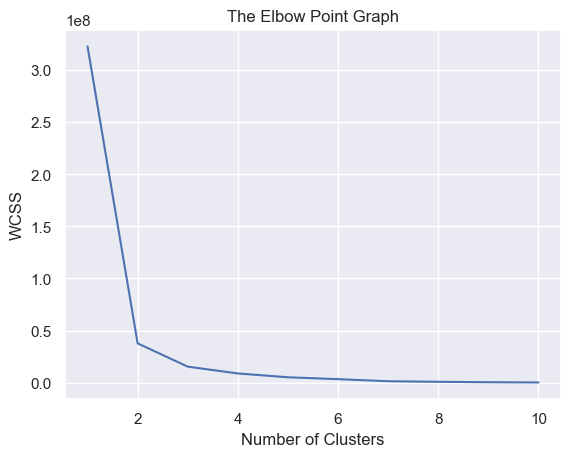

In [54]:
# plot the elbow graph to identify the number of clusters

sns.set()
plt.plot(range(1,11), wcss)
plt.title('The Elbow Point Graph')
plt.xlabel('Number of Clusters')
plt.ylabel('WCSS')
plt.show()

In [55]:
# Optimum number of clusters = '5'

# Training the k-means clustering model

kmeans = KMeans(n_clusters=5, init='k-means++', random_state=0)

# return a label for each data point based on their cluster
Y = kmeans.fit_predict(X)

print(Y)

[3 0 0 1 3 2 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 4
 4 2 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 4 4 4 4 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0 0 0 0 0 0 0 0 0 0 4 0 0 0 0]


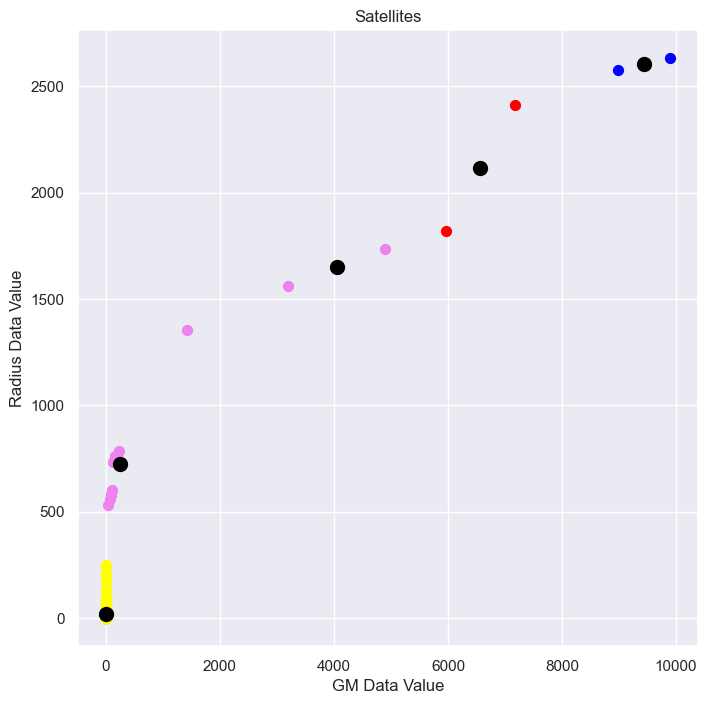

In [56]:
# plotting all the clusters and their centroids

plt.figure(figsize=(8,8))
plt.scatter(X[Y==0,0], X[Y==0,1], s=50, c='yellow', label='Cluster 1')
plt.scatter(X[Y==1,0], X[Y==1,1], s=50, c='red', label='Cluster 2')
plt.scatter(X[Y==2,0], X[Y==2,1], s=50, c='blue', label='Cluster 3')
plt.scatter(X[Y==3,0], X[Y==3,1], s=50, c='violet', label='Cluster 4')
plt.scatter(X[Y==4,0], X[Y==4,1], s=50, c='violet', label='Cluster 5')

# plot the centroid

plt.scatter(kmeans.cluster_centers_[:,0], kmeans.cluster_centers_[:,1], s=100, c='black', label='Centroids')

plt.title('Satellites')
plt.xlabel('GM Data Value')
plt.ylabel('Radius Data Value')
plt.show()